# Gráficamos las observaciones y el ajuste lineal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Importando Archivos

In [2]:
path_mediciones = r"..\mediciones\clase2\clean\mediciones_parte2_clean.csv"
path_ajuste_lineal = r"..\estadistica\clase2\ajuste_lineal_parte2_resultados.csv"

In [3]:
mediciones = pd.read_csv(path_mediciones)
ajuste_lineal = pd.read_csv(path_ajuste_lineal)

In [4]:
mediciones

,vpp_emisor,vpp_receptor,vpp_emisor_error,vpp_receptor_error
0,1.0,0.70,0.03,0.02
1,2.0,1.34,0.06,0.04
2,3.0,2.02,0.09,0.06
3,4.0,2.60,0.10,0.08
4,5.0,3.16,0.10,0.09
5,6.0,3.60,0.20,0.10
6,7.0,4.10,0.20,0.10
7,8.0,4.60,0.20,0.10
8,9.0,5.10,0.30,0.20
9,10.0,5.70,0.30,0.20


In [5]:
ajuste_lineal

,tipo,m,b,m_error,b_error,Cov,R2,Chi2,Chi2_reducido,grados_libertad
0,b libre,0.554765,0.189500,0.004507,0.019592,-0.000055,0.997855,31.616359,1.580818,20
1,b libre,0.555266,0.188453,0.004618,0.019704,-0.000057,0.997622,31.368232,1.650960,19
2,b=0,0.581786,0.000000,0.003537,0.000000,0.000000,0.990604,125.175080,5.960718,21
3,b=0,0.582858,0.000000,0.003606,0.000000,0.000000,0.990161,122.842021,6.142101,20


### Hacemos un cambio de ejes: Vt = m'.Vpp + b'

In [25]:
m_prima = 1 / ajuste_lineal['m']
b_prima = -ajuste_lineal['b'] / ajuste_lineal['m']

In [30]:
m_prima_error = ajuste_lineal['m_error'] / (ajuste_lineal['m'] ** 2)

term1 = (ajuste_lineal['b_error'] / ajuste_lineal['m']) ** 2
term2 = ((ajuste_lineal['b'] * ajuste_lineal['m_error']) / (ajuste_lineal['m'] ** 2)) ** 2
term3 = -2 * (ajuste_lineal['b'] / (ajuste_lineal['m'] ** 3)) * ajuste_lineal['Cov']
b_prima_error = np.sqrt(term1 + term2 + term3)

In [59]:
x = np.linspace(0, mediciones["vpp"].max(), 100)

In [102]:
m = m_prima[4]
b = b_prima[4]
y = m * x + b

In [103]:
print(m, b)
print(m_prima_error[4], b_prima_error[4])

0.1976017227765547 -0.40714966643322725
0.0029586241707211702 0.014652258189998145


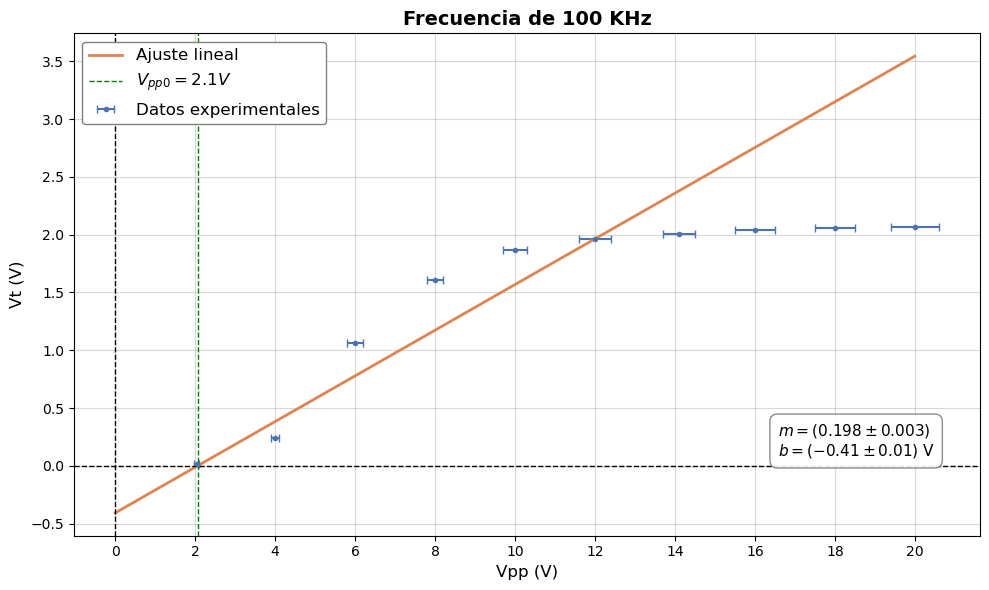

In [104]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    x=mediciones["vpp"],
    y=mediciones["100 KHz"],
    xerr=mediciones["vpp_error"],
    #yerr=mediciones["vt_error"],
    fmt='.',
    capsize=3,
    label='Datos experimentales',
    color='#4C72B0'
)
# Ajuste lineal
plt.plot(x, y, color='#DD8452', label='Ajuste lineal', linewidth=2)

# Tensión de Vpp0 (intersección con el eje x)
plt.axvline(x=ajuste_lineal.iloc[4]['b'], color='green', linestyle='--', linewidth=1, label='$V_{pp0}= ' + '{0:.1f} V$'.format(ajuste_lineal.iloc[4]['b']))

# Línea Horizontal en y = 0
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Línea Vertical en x = 0
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# 1. Definir el texto del cuadro (usando formato de LaTeX en Matplotlib)
texto_box = (
    r"$m = (0.198 \pm 0.003)$" + "\n" +
    r"$b = (-0.41 \pm 0.01)\text{ V}$"
)

# 2. Agregar la caja en la esquina inferior derecha
plt.text(
    0.95, 0.15, texto_box,          # Coordenadas relativas: (X=0.95, Y=0.05) -> abajo a la derecha
    transform=plt.gca().transAxes,  # Usa el sistema de coordenadas de la figura (0 a 1)
    fontsize=11,
    verticalalignment='bottom',
    horizontalalignment='right',
    multialignment='left',
    bbox=dict(
        boxstyle='round,pad=0.5',   # Borde redondeado
        facecolor='white',          # Fondo blanco
        edgecolor='gray',           # Borde gris
        alpha=0.9                   # Opacidad del fondo
    )
)

plt.xticks(np.arange(0, 22, 2))
plt.title('Frecuencia de 100 KHz', fontsize=14, fontweight='bold')
plt.ylabel('Vt (V)', fontsize=12)
plt.xlabel('Vpp (V)', fontsize=12)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.legend(frameon=True, fontsize=12, loc='upper left', facecolor='white', framealpha=1.0, edgecolor='gray')

# guardamos 
path_save = r".\clase1\frecuencia_100KHz.png"
plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()

### Ajuste Lineal Gráfico

In [11]:
f = lambda x, m, b: m * x + b

In [12]:
ajuste_lineal.loc[ajuste_lineal['tipo'] == 'b libre', ['m', 'b']].values[0]

array([0.55476482, 0.18950035])

In [13]:
ajuste_lineal.loc[ajuste_lineal['tipo'] == 'b=0', ['m', 'b']].values[0]

array([0.58178637, 0.        ])

In [24]:
x = np.linspace(0, mediciones["vpp_emisor"].max(), 100)

# b libre
m1 , b1 = ajuste_lineal.loc[ajuste_lineal['tipo'] == 'b libre', ['m', 'b']].values[0]
m2 , b2 = ajuste_lineal.loc[ajuste_lineal['tipo'] == 'b libre', ['m', 'b']].values[1]

# b fijo, b=0
m3, b3 = ajuste_lineal.loc[ajuste_lineal['tipo'] == 'b=0', ['m', 'b']].values[0]
m4, b4 = ajuste_lineal.loc[ajuste_lineal['tipo'] == 'b=0', ['m', 'b']].values[1]

y1 = f(x, m1, b1)
y2 = f(x, m2, b2)
y3 = f(x, m3, b3)
y4 = f(x, m4, b4)

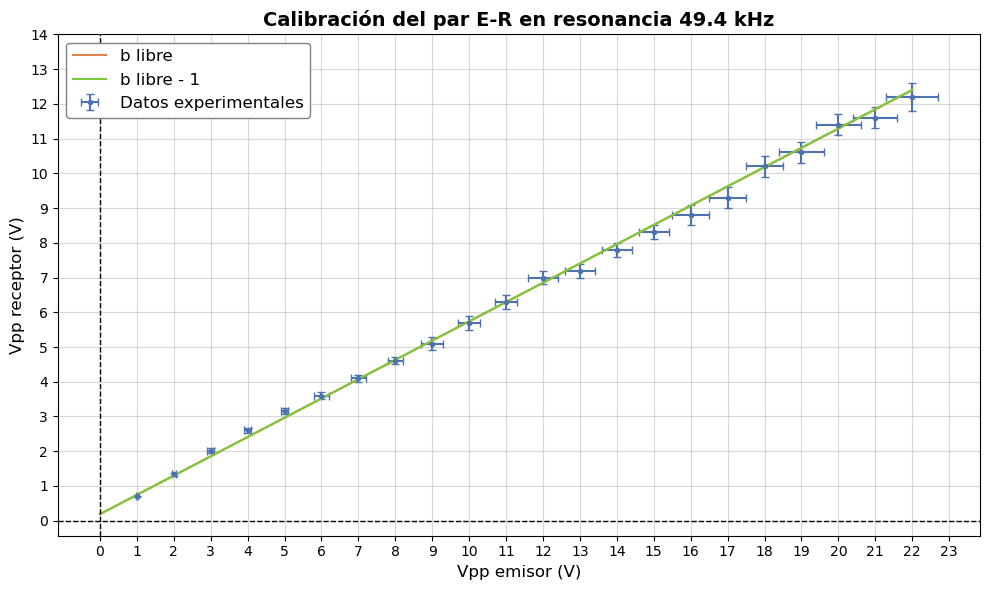

In [26]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    x=mediciones["vpp_emisor"],
    y=mediciones["vpp_receptor"],
    xerr=mediciones["vpp_emisor_error"],
    yerr=mediciones["vpp_receptor_error"],
    fmt='.',
    capsize=3,
    label='Datos experimentales',
    color='#4C72B0'
)
# Ajuste lineal
plt.plot(x, y1, color='#DD8452', label='b libre', linewidth=1.5)
plt.plot(x, y2, color="#79C938", label='b libre - 1', linewidth=1.5)
#plt.plot(x, y3, color="#BE3B57", label='b fijo', linestyle='--', linewidth=1.5)
#plt.plot(x, y4, color="#8B1E31", label='b fijo - 1', linewidth=2)

# Tensión de Vpp0 (intersección con el eje x)
#plt.axvline(x=ajuste_lineal.iloc[4]['b'], color='green', linestyle='--', linewidth=1, label='$V_{pp0}= ' + '{0:.1f} V$'.format(ajuste_lineal.iloc[4]['b']))

# Línea Horizontal en y = 0
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Línea Vertical en x = 0
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# 1. Definir el texto del cuadro (usando formato de LaTeX en Matplotlib)
#texto_box = (
#    r"$m = (0.198 \pm 0.003)$" + "\n" +
#    r"$b = (-0.41 \pm 0.01)\text{ V}$"
#)

# 2. Agregar la caja en la esquina inferior derecha
#plt.text(
#    0.95, 0.15, texto_box,          # Coordenadas relativas: (X=0.95, Y=0.05) -> abajo a la derecha
#    transform=plt.gca().transAxes,  # Usa el sistema de coordenadas de la figura (0 a 1)
#    fontsize=11,
#    verticalalignment='bottom',
#    horizontalalignment='right',
#    multialignment='left',
#    bbox=dict(
#        boxstyle='round,pad=0.5',   # Borde redondeado
#        facecolor='white',          # Fondo blanco
#        edgecolor='gray',           # Borde gris
#        alpha=0.9                   # Opacidad del fondo
#    )
#)

plt.xticks(np.arange(0, 24,))
plt.yticks(np.arange(0, 15,))

plt.title('Calibración del par E-R en resonancia 49.4 kHz', fontsize=14, fontweight='bold')
plt.ylabel('Vpp receptor (V)', fontsize=12)
plt.xlabel('Vpp emisor (V)', fontsize=12)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.legend(frameon=True, fontsize=12, loc='upper left', facecolor='white', framealpha=1.0, edgecolor='gray')

# guardamos 
#path_save = r".\clase1\frecuencia_100KHz.png"
#plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()

In [27]:
ajuste_lineal["b_error"]

0    0.019592
1    0.019704
2    0.000000
3    0.000000
Name: b_error, dtype: float64

In [28]:
b1 - ajuste_lineal["b_error"][0], b1 + ajuste_lineal["b_error"][0]


(np.float64(0.1699088415837833), np.float64(0.2090918590512815))

In [29]:
b2 - ajuste_lineal["b_error"][1], b2 + ajuste_lineal["b_error"][1]


(np.float64(0.16874898125852472), np.float64(0.2081570086847015))

In [30]:
m2, m3

(np.float64(0.5552656380938069), np.float64(0.5817863748542695))

In [23]:
ajuste_lineal.loc[ajuste_lineal['tipo'] == 'b libre', ['m', 'b']].values[1]

array([0.55526564, 0.18845299])